In [1]:
%cd ..

/scratch/big/home/daawic/BSc-Thesis


In [2]:
import os
import torch
import matplotlib.pyplot as plt
from torchvision.transforms import transforms
from project.models import EDMMauMau, EDMLuomen
from project.util.device import get_available_acc
from project.util.transforms import Difference
from project.util.data import ReplayMemoryData
from project.util.metrics import PSNR, MSE

In [3]:
PATH = os.path.join("..", "checkpoints", "diff", "Breakout.pt")
DATA = os.path.join("..", "checkpoints", "memory", "Breakout_test.pt")
N = 9

In [4]:
device = "cuda:9"

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Pad(2),
    Difference(),
    transforms.Normalize(0.5, 0.5),
])

In [6]:
data = ReplayMemoryData(
    memory=DATA,
    transform=transform,
    cap=10_000
)

In [7]:
psnrs = []
psnrs_naive = []

mses = []
mses_naive = []

n = 64

x = torch.zeros((n, 7, 88, 88), device=device)

for i, img in enumerate(torch.randperm(10_000)[:n]):
    x[i] = data[img].to(device)

sigmas = torch.linspace(0, 1, 20)

for sigma in sigmas:

    model = EDMLuomen.from_checkpoint(PATH, device, sigma_noise=sigma, N=N).to(device)
    model_naive = EDMMauMau.from_checkpoint(PATH, device, sigma_noise=sigma).to(device)

    e = sigma * torch.randn_like(x)
    x_noisy = (x + e).clip(-1, 1)

    with torch.no_grad():
        x_denoised = model.denoise(x_noisy)
        x_denoised_naive = model_naive.denoise(x_noisy)
        psnrs.append(PSNR(x[:4].to("cpu"), x_denoised[:4].to("cpu"), torch.tensor(2)))
        psnrs_naive.append(PSNR(x[:4].to("cpu"), x_denoised_naive[:4].to("cpu"), torch.tensor(2)))
        mses.append(MSE(x[:4].to("cpu"), x_denoised[:4].to("cpu")))
        mses_naive.append(MSE(x[:4].to("cpu"), x_denoised_naive[:4].to("cpu")))
    
    print(f"Finished {sigma}")

/scratch/big/home/daawic/BSc-Thesis/project/models/denoise_edm.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dist = (sigmas - torch.tensor(self._sigma_noise)).abs()
100%|██████████| 1/1 [00:01<00:00,  1.23s/it]


Finished 0.0


100%|██████████| 2/2 [00:00<00:00,  2.21it/s]


Finished 0.05263157933950424


100%|██████████| 3/3 [00:01<00:00,  1.75it/s]


...

Finished 0.8947368264198303


100%|██████████| 4/4 [00:02<00:00,  1.58it/s]


Finished 0.9473684430122375


100%|██████████| 4/4 [00:02<00:00,  1.58it/s]


Finished 1.0


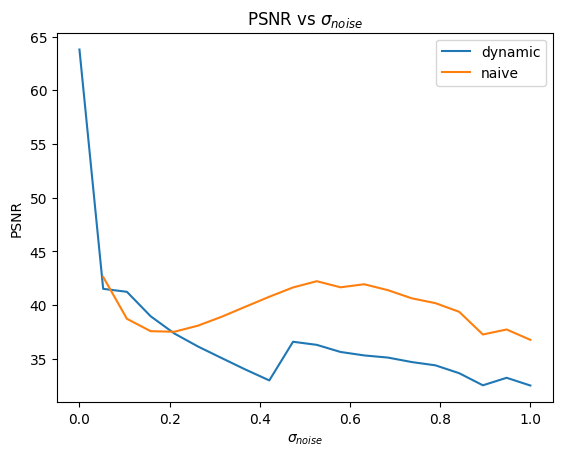

In [8]:
plt.plot(sigmas, psnrs, label="dynamic")
plt.plot(sigmas, psnrs_naive, label="naive")
plt.xlabel("$\\sigma_{noise}$")
plt.ylabel("PSNR")
plt.title("PSNR vs $\\sigma_{noise}$")
plt.legend()
plt.show()

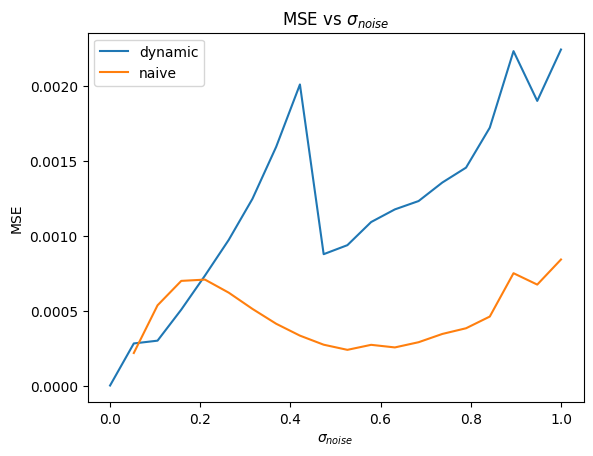

In [9]:
plt.plot(sigmas, mses, label="dynamic")
plt.plot(sigmas, mses_naive, label="naive")
plt.xlabel("$\\sigma_{noise}$")
plt.ylabel("MSE")
plt.title("MSE vs $\\sigma_{noise}$")
plt.legend()
plt.show()